In [1]:
import os

import numpy as np
import random
import json

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.preprocessing import StandardScaler

import lightgbm as lgb

import joblib

In [2]:
DIR_DATA="./data/Dataset/"
DIR_NET_SAVING="./data/net/"
DIR_RESULTS="./data/"

In [3]:
manualSeed = 1

random.seed(manualSeed)

np.random.seed(manualSeed)

In [4]:
def remove_outliers(data_dict):
    features = np.array(data_dict["features"])
    labels = np.array(data_dict["label"])

    # Calculate thresholds for each of the 15 features independently
    borne_min = np.quantile(features, 0.01, axis=0)
    borne_max = np.quantile(features, 0.99, axis=0)

    # Create a boolean mask where True means the row is within the 1% - 99% range for ALL features
    is_good_row = np.all((features >= borne_min) & (features <= borne_max), axis=1)

    # Filter and update the dictionary with clean data
    data_dict["features"] = features[is_good_row].tolist()
    data_dict["label"] = labels[is_good_row].tolist()

    return data_dict



def clean_subject_dataset(data_dict):
    features = np.array(data_dict["features"])
    labels = np.array(data_dict["label"])

    clean_features_list = []
    clean_labels_list = []

    # Process each of the 4 emotional states (labels 1 to 4) separately
    for state_label in range(1, 5):
        # Mask to isolate the current state
        state_mask = labels == state_label

        # Skip if this specific state has no data points
        if not np.any(state_mask):
            continue

        state_dict = {
            "features": features[state_mask].tolist(),
            "label": labels[state_mask].tolist(),
        }

        # Apply our updated outlier removal function to this state
        cleaned_state_dict = remove_outliers(state_dict)

        # Collect the cleaned data
        clean_features_list.extend(cleaned_state_dict["features"])
        clean_labels_list.extend(cleaned_state_dict["label"])

    # Return the fully reconstructed clean dataset
    return {"features": clean_features_list, "label": clean_labels_list}


def merge_subject_datasets(dataset_list):
    combined_features = []
    combined_labels = []

    for data_dict in dataset_list:
        combined_features.append(np.array(data_dict["features"]))
        combined_labels.append(np.array(data_dict["label"]))

    # Use np.vstack and np.concatenate for high-speed memory block stitching
    return {
        "features": np.vstack(combined_features).tolist(),
        "label": np.concatenate(combined_labels).tolist(),
    }

import numpy as np


def downsample_to_target(data_dict, indices, target_size):

    selected_indices = np.random.choice(
        indices,
        target_size,
        replace=False
    )

    features = [data_dict["features"][idx] for idx in selected_indices]
    labels = [data_dict["label"][idx] for idx in selected_indices]

    return features, labels


def balance_subject_dataset(data_dict):
    labels = np.array(data_dict["label"])

    # Find indices for each class
    idx_neutral = np.where(labels == 1)[0]
    idx_stress = np.where(labels == 2)[0]
    idx_amusement = np.where(labels == 3)[0]
    idx_meditation = np.where(labels == 4)[0]

    # Stress (Label 2) is our anchor target size
    stress_count = len(idx_stress)

    # Split that target size equally among the 3 non-stress classes
    target_per_non_stress = stress_count // 3

    balanced_features = []
    balanced_labels = []

    # Downsample and collect each class
    # 1. Neutral
    f_neut, l_neut = downsample_to_target(
        data_dict, idx_neutral, target_per_non_stress
    )
    balanced_features.extend(f_neut)
    balanced_labels.extend(l_neut)

    # 2. Stress (Keep 100% of it, no downsampling needed)
    f_str = [data_dict["features"][idx] for idx in idx_stress]
    l_str = [data_dict["label"][idx] for idx in idx_stress]
    balanced_features.extend(f_str)
    balanced_labels.extend(l_str)

    # 3. Amusement
    f_amu, l_amu = downsample_to_target(
        data_dict, idx_amusement, target_per_non_stress
    )
    balanced_features.extend(f_amu)
    balanced_labels.extend(l_amu)

    # 4. Meditation
    f_med, l_med = downsample_to_target(
        data_dict, idx_meditation, target_per_non_stress
    )
    balanced_features.extend(f_med)
    balanced_labels.extend(l_med)

    return {"features": balanced_features, "label": balanced_labels}

In [5]:
# ============================================================
# Utility Functions for LightGBM
# ============================================================

from sklearn.preprocessing import StandardScaler


def dict_to_xy(data_dict):
    """
    Convert dataset dictionary into:

        X : feature matrix (N, 15)
        y : binary target vector

    Label mapping:
        Stress (2)              -> 1
        Neutral (1)             -> 0
        Amusement (3)           -> 0
        Meditation (4)          -> 0
    """

    X = np.array(
        data_dict["features"],
        dtype=np.float32
    )

    raw_labels = np.array(
        data_dict["label"],
        dtype=np.int32
    )

    y = np.where(
        raw_labels == 2,
        1,
        0
    ).astype(np.int32)

    return X, y


def prepare_fold_data(train_dict, val_dict):
    """
    Prepare one CV fold for LightGBM.

    Steps:
        1. Convert dictionaries to X/y
        2. Fit StandardScaler on training data only
        3. Transform validation data using the same scaler
        4. Return scaled arrays

    Returns:
        X_train
        y_train
        X_val
        y_val
        scaler
    """

    # ----------------------------------------
    # Dictionary -> NumPy
    # ----------------------------------------

    X_train, y_train = dict_to_xy(train_dict)

    X_val, y_val = dict_to_xy(val_dict)

    # ----------------------------------------
    # Standardization
    # IMPORTANT:
    # Fit only on training data
    # ----------------------------------------

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)

    X_val = scaler.transform(X_val)

    return (
        X_train,
        y_train,
        X_val,
        y_val,
        scaler
    )

In [6]:
# ============================================================
# Subject List
# S17 is excluded because it is reserved as the final holdout test subject
# ============================================================

name_list = [
    "WESADECG_S2.json",
    "WESADECG_S3.json",
    "WESADECG_S4.json",
    "WESADECG_S5.json",
    "WESADECG_S6.json",
    "WESADECG_S7.json",
    "WESADECG_S8.json",
    "WESADECG_S9.json",
    "WESADECG_S10.json",
    "WESADECG_S11.json",
    "WESADECG_S13.json",
    "WESADECG_S14.json",
    "WESADECG_S15.json",
    "WESADECG_S16.json",
]

# ============================================================
# Step 1: Pre-load, balance, and clean each subject
# ============================================================

print("Pre-loading, balancing, and cleaning subject data...")

preloaded_subjects = []

for file_name in name_list:

    file_path = os.path.join(DIR_DATA, file_name)

    with open(file_path, "r") as f:
        raw_data = json.load(f)

    balanced_data = balance_subject_dataset(raw_data)

    clean_data = clean_subject_dataset(balanced_data)

    preloaded_subjects.append(clean_data)

print(f"Successfully cached {len(preloaded_subjects)} subjects in memory.\n")


# ============================================================
# Step 2: Generate leave-2-subjects-out CV splits
# ============================================================

print("Generating cross-validation splits...")

cv_splits = []
combination_counter = 0
num_subjects = len(name_list)

for k in range(num_subjects):

    for j in range(k + 1, num_subjects):

        val_subject_1 = preloaded_subjects[k]
        val_subject_2 = preloaded_subjects[j]

        dict_val_combined = merge_subject_datasets(
            [val_subject_1, val_subject_2]
        )

        train_subjects_pool = []

        for i in range(num_subjects):

            if i != k and i != j:
                train_subjects_pool.append(preloaded_subjects[i])

        assert len(train_subjects_pool) == num_subjects - 2

        dict_train_combined = merge_subject_datasets(
            train_subjects_pool
        )

        cv_splits.append({
            "train_dict": dict_train_combined,
            "val_dict": dict_val_combined,
            "val_idx_1": k,
            "val_idx_2": j,
        })

        combination_counter += 1

        if combination_counter % 10 == 0:
            print(f"Generated {combination_counter}/91 splits...")

print(f"\nFinal: Generated {len(cv_splits)} distinct validation folds.")

Pre-loading, balancing, and cleaning subject data...
Successfully cached 14 subjects in memory.

Generating cross-validation splits...
Generated 10/91 splits...
Generated 20/91 splits...
Generated 30/91 splits...
Generated 40/91 splits...
Generated 50/91 splits...
Generated 60/91 splits...
Generated 70/91 splits...
Generated 80/91 splits...
Generated 90/91 splits...

Final: Generated 91 distinct validation folds.


In [7]:
# ============================================================
# LightGBM Model Factory
# ============================================================

def create_lightgbm_model(random_state=42):

    return lgb.LGBMClassifier(

        objective="binary",

        boosting_type="gbdt",

        n_estimators=500,

        learning_rate=0.03,

        num_leaves=15,

        max_depth=4,

        min_child_samples=20,

        subsample=0.8,

        colsample_bytree=0.8,

        reg_alpha=0.1,

        reg_lambda=1.0,

        random_state=random_state,

        n_jobs=-1
    )

In [8]:
# ============================================================
# Train One LightGBM Fold
# ============================================================

def train_lightgbm_fold(
    train_dict,
    val_dict,
    random_state=42
):

    # ----------------------------------------
    # Prepare data
    # ----------------------------------------

    X_train, y_train, X_val, y_val, scaler = (
        prepare_fold_data(
            train_dict,
            val_dict
        )
    )

    # ----------------------------------------
    # Create model
    # ----------------------------------------

    model = create_lightgbm_model(
        random_state=random_state
    )

    # ----------------------------------------
    # Train
    # ----------------------------------------

    model.fit(
        X_train,
        y_train,

        eval_set=[
            (X_val, y_val)
        ],

        eval_metric="binary_logloss",

        callbacks=[
            lgb.early_stopping(
                stopping_rounds=30,
                verbose=False
            )
        ]
    )

    # ----------------------------------------
    # Predictions
    # ----------------------------------------

    y_prob = model.predict_proba(X_val)[:, 1]

    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    # ----------------------------------------
    # Metrics
    # ----------------------------------------

    acc = accuracy_score(
        y_val,
        y_pred
    )

    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_val,
        y_prob
    )

    conf_matrix = confusion_matrix(
        y_val,
        y_pred,
        labels=[0, 1]
    )

    return {
    
        "model": model,
    
        "scaler": scaler,
    
        "accuracy": acc,
    
        "precision": precision,
    
        "recall": recall,
    
        "f1": f1,
    
        "auc": auc,
    
        "confusion_matrix": conf_matrix,
    
        "best_iteration": model.best_iteration_,
    
        "y_true": y_val.tolist(),
    
        "y_prob": y_prob.tolist()
    }

In [9]:
# ============================================================
# LightGBM Cross Validation
# ============================================================

model_folder = "trained_models_lightgbm"

os.makedirs(
    model_folder,
    exist_ok=True
)

results = []

print("Running LightGBM Cross Validation...")

for n, split in enumerate(
    tqdm(
        cv_splits,
        desc="LightGBM CV"
    )
):

    fold_result = train_lightgbm_fold(

        train_dict=split["train_dict"],

        val_dict=split["val_dict"],

        random_state=42 + n
    )

    # --------------------------------------------------------
    # Save Model
    # --------------------------------------------------------

    model_path = os.path.join(

        model_folder,

        f"lgbm_{split['val_idx_1']}_{split['val_idx_2']}.pkl"
    )

    joblib.dump(
        {
            "model": fold_result["model"],
            "scaler": fold_result["scaler"]
        },
        model_path
    )

    # --------------------------------------------------------
    # Save Fold Metrics
    # --------------------------------------------------------

    results.append({
    
        "idx1": split["val_idx_1"],
    
        "idx2": split["val_idx_2"],
    
        "accuracy": fold_result["accuracy"],
    
        "precision": fold_result["precision"],
    
        "recall": fold_result["recall"],
    
        "f1": fold_result["f1"],
    
        "auc": fold_result["auc"],
    
        "best_iteration": fold_result["best_iteration"],
    
        "confusion_matrix":
            fold_result["confusion_matrix"].tolist(),
    
        "y_true":
            fold_result["y_true"],
    
        "y_prob":
            fold_result["y_prob"]
    })

print(
    "\nLightGBM cross-validation completed successfully."
)

with open(
    os.path.join(
        DIR_RESULTS,
        "lightgbm_cv_results.json"
    ),
    "w"
) as f:

    json.dump(
        results,
        f,
        indent=4
    )

Running LightGBM Cross Validation...


LightGBM CV:   0%|                                  | 0/91 [00:00<?, ?it/s]/Users/sasakitomo/Desktop/Summer Project/MyCode/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/sasakitomo/Desktop/Summer Project/MyCode/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
LightGBM CV:   2%|▌                         | 2/91 [00:00<00:06, 13.33it/s]

[LightGBM] [Info] Number of positive: 1169, number of negative: 1053
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000354 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3766
[LightGBM] [Info] Number of data points in the train set: 2222, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.526103 -> initscore=0.104505
[LightGBM] [Info] Start training from score 0.104505
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

/Users/sasakitomo/Desktop/Summer Project/MyCode/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/sasakitomo/Desktop/Summer Project/MyCode/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
LightGBM CV:   4%|█▏                        | 4/91 [00:00<00:06, 13.18it/s]

[LightGBM] [Info] Number of positive: 1170, number of negative: 1053
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000173 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3780
[LightGBM] [Info] Number of data points in the train set: 2223, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.526316 -> initscore=0.105361
[LightGBM] [Info] Start training from score 0.105361
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/Users/sasakitomo/Desktop/Summer Project/MyCode/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
LightGBM CV:  99%|████████████████████████▋| 90/91 [00:15<00:00,  7.03it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1159, number of negative: 1033
[LightGBM] [Info] Auto-choosing

/Users/sasakitomo/Desktop/Summer Project/MyCode/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
LightGBM CV: 100%|█████████████████████████| 91/91 [00:15<00:00,  5.90it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

acc_scores = []
prec_scores = []
recall_scores = []
f1_scores = []

for threshold in thresholds:

    fold_acc = []
    fold_prec = []
    fold_rec = []
    fold_f1 = []

    for r in results:

        y_true = np.array(
            r["y_true"]
        )

        y_prob = np.array(
            r["y_prob"]
        )

        y_pred = (
            y_prob >= threshold
        ).astype(int)

        fold_acc.append(
            accuracy_score(
                y_true,
                y_pred
            )
        )

        fold_prec.append(
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            )
        )

        fold_rec.append(
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            )
        )

        fold_f1.append(
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            )
        )

    acc_scores.append(
        np.mean(fold_acc)
    )

    prec_scores.append(
        np.mean(fold_prec)
    )

    recall_scores.append(
        np.mean(fold_rec)
    )

    f1_scores.append(
        np.mean(fold_f1)
    )

In [11]:
acc_list = [r["accuracy"] for r in results]
prec_list = [r["precision"] for r in results]
recall_list = [r["recall"] for r in results]
f1_list = [r["f1"] for r in results]
auc_list = [r["auc"] for r in results]

print(f"Accuracy : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"Precision: {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
print(f"Recall   : {np.mean(recall_list):.4f} ± {np.std(recall_list):.4f}")
print(f"F1 Score : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
print(f"ROC-AUC  : {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")

Accuracy : 0.7819 ± 0.1196
Precision: 0.8526 ± 0.1258
Recall   : 0.7338 ± 0.2383
F1 Score : 0.7601 ± 0.1619
ROC-AUC  : 0.8696 ± 0.1146


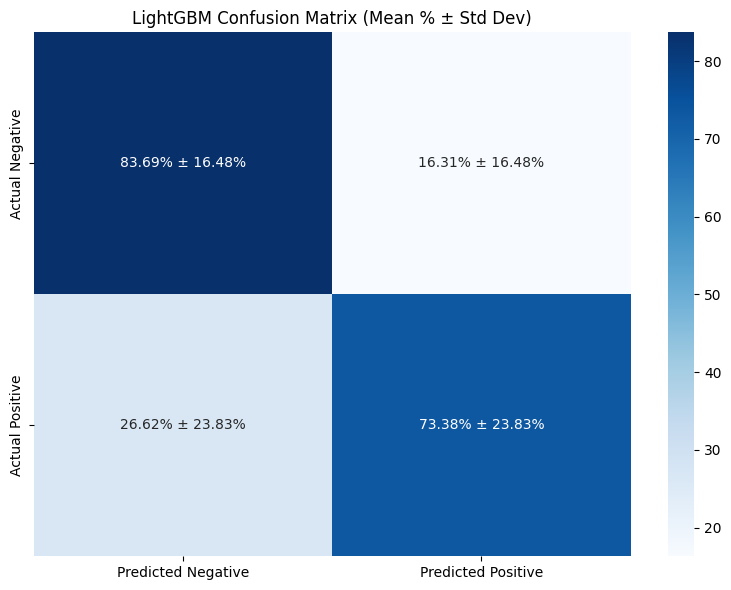

In [12]:
# ============================================================
# LightGBM Mean Confusion Matrix
# ============================================================

confusion_list = []

for r in results:

    cm = np.array(
        r["confusion_matrix"]
    )

    # Row-wise normalization
    row_normalized = cm / np.maximum(
        cm.sum(axis=1, keepdims=True),
        1
    )

    confusion_list.append(
        100 * row_normalized
    )

# ------------------------------------------------------------
# Mean & Std
# ------------------------------------------------------------

conf_mean = np.round(
    np.mean(confusion_list, axis=0),
    2
)

conf_std = np.round(
    np.std(confusion_list, axis=0),
    2
)

# ------------------------------------------------------------
# Annotation strings
# ------------------------------------------------------------

annot_conf = [
    [
        f"{m:.2f}% ± {s:.2f}%"
        for m, s in zip(row_m, row_s)
    ]
    for row_m, row_s in zip(conf_mean, conf_std)
]

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_mean,
    annot=annot_conf,
    fmt="",
    cmap="Blues",

    xticklabels=[
        "Predicted Negative",
        "Predicted Positive"
    ],

    yticklabels=[
        "Actual Negative",
        "Actual Positive"
    ]
)

plt.title(
    "LightGBM Confusion Matrix (Mean % ± Std Dev)"
)

plt.tight_layout()

plt.show()

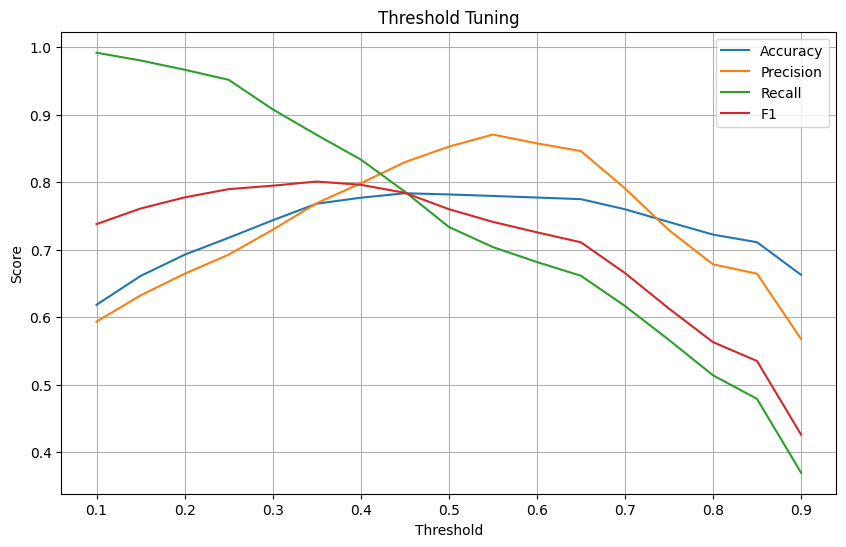

In [13]:
plt.figure(figsize=(10,6))

plt.plot(
    thresholds,
    acc_scores,
    label="Accuracy"
)

plt.plot(
    thresholds,
    prec_scores,
    label="Precision"
)

plt.plot(
    thresholds,
    recall_scores,
    label="Recall"
)

plt.plot(
    thresholds,
    f1_scores,
    label="F1"
)

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.title(
    "Threshold Tuning"
)

plt.legend()

plt.grid()

plt.show()

In [14]:
# threshold = 0.35 might be the best

In [15]:
best_idx = np.argmax(
    f1_scores
)

print(
    f"Best Threshold = {thresholds[best_idx]:.2f}"
)

print(
    f"F1 = {f1_scores[best_idx]:.4f}"
)

print(
    f"Recall = {recall_scores[best_idx]:.4f}"
)

print(
    f"Precision = {prec_scores[best_idx]:.4f}"
)

print(
    f"Accuracy = {acc_scores[best_idx]:.4f}"
)

Best Threshold = 0.35
F1 = 0.8010
Recall = 0.8700
Precision = 0.7689
Accuracy = 0.7682


In [16]:
# ============================================================
# Load Holdout Subject S17
# ============================================================

TEST_DATA="./data/Testing/"


s17_path = os.path.join(
    TEST_DATA,
    "WESADECG_S17.json"
)

with open(s17_path, "r") as f:

    s17_raw = json.load(f)

# Same preprocessing as training subjects

s17_balanced = balance_subject_dataset(
    s17_raw
)

s17_clean = clean_subject_dataset(
    s17_balanced
)

print(
    f"S17 samples: {len(s17_clean['label'])}"
)

S17 samples: 203


In [17]:
# ============================================================
# Build Full Training Dataset
# ============================================================

full_train_dict = merge_subject_datasets(
    preloaded_subjects
)

print(
    f"Training samples: {len(full_train_dict['label'])}"
)

Training samples: 2567


In [18]:
# ============================================================
# Train Model on S2-S16
# ============================================================

X_train, y_train = dict_to_xy(
    full_train_dict
)

X_test, y_test = dict_to_xy(
    s17_clean
)

# ------------------------------------------------------------
# Scaling
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

model = create_lightgbm_model(
    random_state=42
)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

model.fit(
    X_train,
    y_train
)

print("Training completed.")

[LightGBM] [Info] Number of positive: 1350, number of negative: 1217
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000278 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3796
[LightGBM] [Info] Number of data points in the train set: 2567, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.525906 -> initscore=0.103716
[LightGBM] [Info] Start training from score 0.103716
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [19]:
# ============================================================
# Holdout Evaluation on S17
# ============================================================

THRESHOLD = 0.35

y_prob = model.predict_proba(
    X_test
)[:,1]

y_pred = (
    y_prob >= THRESHOLD
).astype(int)

acc = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

auc = roc_auc_score(
    y_test,
    y_prob
)

print("\n=== S17 Holdout Test ===")

print(f"Accuracy : {acc:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print(f"ROC-AUC  : {auc:.4f}")


=== S17 Holdout Test ===
Accuracy : 0.9754
Precision: 0.9902
Recall   : 0.9619
F1 Score : 0.9758
ROC-AUC  : 0.9993


/Users/sasakitomo/Desktop/Summer Project/MyCode/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


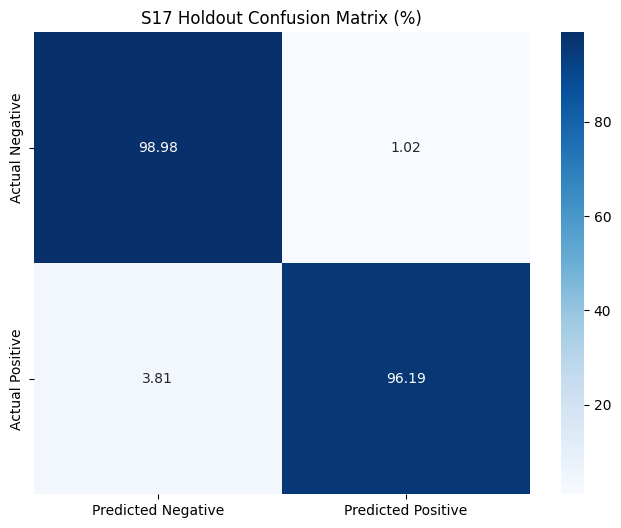

In [20]:
# ============================================================
# S17 Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0,1]
)

row_normalized = cm / np.maximum(
    cm.sum(axis=1, keepdims=True),
    1
)

conf_percent = 100 * row_normalized

plt.figure(figsize=(8,6))

sns.heatmap(
    conf_percent,

    annot=True,

    fmt=".2f",

    cmap="Blues",

    xticklabels=[
        "Predicted Negative",
        "Predicted Positive"
    ],

    yticklabels=[
        "Actual Negative",
        "Actual Positive"
    ]
)

plt.title(
    "S17 Holdout Confusion Matrix (%)"
)

plt.show()

In [21]:
print(len(y_test))
print(np.bincount(y_test))

203
[ 98 105]


In [22]:
# ============================================================
# Train Final Production Model
# ============================================================

print("Training final production model...")

# ------------------------------------------------------------
# Merge all available training subjects
# (S2-S16)
# ------------------------------------------------------------

full_train_dict = merge_subject_datasets(
    preloaded_subjects
)

# ------------------------------------------------------------
# Convert to X / y
# ------------------------------------------------------------

X_full, y_full = dict_to_xy(
    full_train_dict
)

# ------------------------------------------------------------
# Fit final scaler
# ------------------------------------------------------------

final_scaler = StandardScaler()

X_full = final_scaler.fit_transform(
    X_full
)

# ------------------------------------------------------------
# Create final LightGBM model
# ------------------------------------------------------------

final_model = create_lightgbm_model(
    random_state=42
)

# ------------------------------------------------------------
# Train on ALL available data
# ------------------------------------------------------------

final_model.fit(
    X_full,
    y_full
)

# ------------------------------------------------------------
# Final threshold selected from threshold tuning
# ------------------------------------------------------------

FINAL_THRESHOLD = 0.35

# ------------------------------------------------------------
# Bundle everything into ONE file
# ------------------------------------------------------------

stress_bundle = {

    "model": final_model,

    "scaler": final_scaler,

    "threshold": FINAL_THRESHOLD,

    "feature_names": [
        f"feature_{i}"
        for i in range(X_full.shape[1])
    ],

    "feature_count": X_full.shape[1],

    "training_samples": len(y_full),

    "training_subjects": len(preloaded_subjects),

    "model_type": "LightGBM",

    "version": "1.0"
}

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

MODEL_PATH = "stress_model_60s.pkl"

joblib.dump(
    stress_bundle,
    MODEL_PATH
)

print("\n===================================")
print("Final model saved successfully")
print("===================================")

print(f"File      : {MODEL_PATH}")
print(f"Samples   : {len(y_full)}")
print(f"Features  : {X_full.shape[1]}")
print(f"Threshold : {FINAL_THRESHOLD}")

Training final production model...
[LightGBM] [Info] Number of positive: 1350, number of negative: 1217
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000223 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3796
[LightGBM] [Info] Number of data points in the train set: 2567, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.525906 -> initscore=0.103716
[LightGBM] [Info] Start training from score 0.103716
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

In [23]:
bundle = joblib.load(
    "stress_model_60s.pkl"
)

print(bundle.keys())

dict_keys(['model', 'scaler', 'threshold', 'feature_names', 'feature_count', 'training_samples', 'training_subjects', 'model_type', 'version'])
